# Análisis de Prueba A/B: Sistema de Recomendaciones
## Tienda en Línea Internacional

---

## Tabla de Contenidos

1. [Introducción y Objetivos](#1-introduccion)
2. [Carga de Datos y Librerías](#2-carga)
3. [Exploración y Calidad de Datos](#3-exploracion)
   - 3.1 [Estructura de los Datos](#31-estructura)
   - 3.2 [Tipos de Datos y Conversiones](#32-tipos)
   - 3.3 [Valores Ausentes y Duplicados](#33-ausentes)
4. [Preprocesamiento](#4-preprocesamiento)
5. [Análisis Exploratorio de Datos (EDA)](#5-eda)
   - 5.1 [Verificación de Condiciones del Test](#51-condiciones)
   - 5.2 [Análisis de Eventos de Marketing](#52-marketing)
   - 5.3 [Análisis del Embudo de Conversión](#53-embudo)
   - 5.4 [Distribución Temporal de Eventos](#54-temporal)
6. [Evaluación Estadística del Test A/B](#6-evaluacion)
   - 6.1 [Formulación de Hipótesis](#61-hipotesis)
   - 6.2 [Test Z de Proporciones](#62-test-z)
   - 6.3 [Interpretación de Resultados](#63-interpretacion)
7. [Conclusiones y Recomendaciones](#7-conclusiones)

<a id='1-introduccion'></a>
## 1. Introducción y Objetivos

### 1.1 Contexto del Negocio

Una tienda en línea internacional ha implementado un nuevo **sistema de recomendaciones** con el objetivo de mejorar la experiencia de compra de los usuarios. Para evaluar su efectividad, se diseñó una prueba A/B donde:

- **Grupo A (Control):** Usuarios expuestos al embudo de pago tradicional
- **Grupo B (Tratamiento):** Usuarios expuestos al nuevo sistema de recomendaciones

### 1.2 Especificaciones Técnicas del Test

| Parámetro | Especificación |
|-----------|----------------|
| **Nombre del test** | `recommender_system_test` |
| **Fecha de inicio** | 7 de diciembre de 2020 |
| **Fin de inscripción** | 21 de diciembre de 2020 |
| **Fecha de finalización** | 1 de enero de 2021 |
| **Duración total** | 25 días |
| **Audiencia objetivo** | 15% de nuevos usuarios de la región EU |
| **Tamaño de muestra esperado** | 6,000 usuarios |

### 1.3 Hipótesis del Negocio

> *"El nuevo sistema de recomendaciones producirá un aumento de al menos **10%** en la tasa de conversión en cada etapa del embudo de compra (product_page → product_cart → purchase) dentro de los 14 días posteriores al registro."*

### 1.4 Objetivos del Análisis

1. **Verificar la correcta implementación** del test A/B según las especificaciones
2. **Identificar anomalías o factores de confusión** que puedan afectar los resultados
3. **Evaluar estadísticamente** si existe diferencia significativa entre los grupos
4. **Determinar si se cumple** la expectativa de mejora del 10%
5. **Proporcionar recomendaciones** basadas en evidencia

<a id='2-carga'></a>
## 2. Carga de Datos y Librerías

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
from scipy import stats
from datetime import datetime, timedelta
import warnings

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuración del entorno
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Configuración de Seaborn
sns.set_style('whitegrid')
sns.set_palette('husl')

# Configuración de Plotly
import plotly.io as pio
pio.templates.default = 'plotly_white'

print('✓ Entorno configurado correctamente')
print('  - Pandas, NumPy, SciPy')
print('  - Matplotlib, Seaborn (gráficos estáticos)')
print('  - Plotly (gráficos interactivos)')

✓ Entorno configurado correctamente
  - Pandas, NumPy, SciPy
  - Matplotlib, Seaborn (gráficos estáticos)
  - Plotly (gráficos interactivos)


In [2]:
# Carga de los datasets
marketing_events = pd.read_csv('../ab_project_marketing_events_us.csv')
new_users = pd.read_csv('../final_ab_new_users_upd_us.csv')
events = pd.read_csv('../final_ab_events_upd_us.csv')
participants = pd.read_csv('../final_ab_participants_upd_us.csv')

# Resumen de datos cargados
print('DATASETS CARGADOS:')
print('=' * 50)
datasets = {
    'Marketing Events': marketing_events,
    'New Users': new_users,
    'Events': events,
    'Participants': participants
}

for name, df in datasets.items():
    print(f'{name:20} | {df.shape[0]:>10,} filas | {df.shape[1]:>3} columnas')

DATASETS CARGADOS:
Marketing Events     |         14 filas |   4 columnas
New Users            |     58,703 filas |   4 columnas
Events               |    423,761 filas |   4 columnas
Participants         |     14,525 filas |   3 columnas


<a id='3-exploracion'></a>
## 3. Exploración y Calidad de Datos

<a id='31-estructura'></a>
### 3.1 Estructura de los Datos

Antes de realizar cualquier análisis, es fundamental entender la estructura de cada dataset y verificar la integridad de los datos.

In [3]:
# Explorar cada dataset
for name, df in datasets.items():
    print(f'\n{"="*60}')
    print(f' {name.upper()}')
    print(f'{"="*60}')
    print(f'\nColumnas: {list(df.columns)}')
    print(f'\nPrimeras 3 filas:')
    display(df.head(3))


 MARKETING EVENTS

Columnas: ['name', 'regions', 'start_dt', 'finish_dt']

Primeras 3 filas:


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19



 NEW USERS

Columnas: ['user_id', 'first_date', 'region', 'device']

Primeras 3 filas:


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC



 EVENTS

Columnas: ['user_id', 'event_dt', 'event_name', 'details']

Primeras 3 filas:


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99



 PARTICIPANTS

Columnas: ['user_id', 'group', 'ab_test']

Primeras 3 filas:


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test


<a id='32-tipos'></a>
### 3.2 Tipos de Datos y Conversiones Necesarias

Es importante verificar que cada columna tenga el tipo de dato correcto para el análisis. Las columnas de fecha deben ser de tipo `datetime` para poder realizar operaciones temporales.

In [4]:
# Verificar tipos de datos
print('TIPOS DE DATOS ORIGINALES:')
print('=' * 60)
for name, df in datasets.items():
    print(f'\n{name}:')
    for col in df.columns:
        print(f'  {col:15} → {df[col].dtype}')

TIPOS DE DATOS ORIGINALES:

Marketing Events:
  name            → object
  regions         → object
  start_dt        → object
  finish_dt       → object

New Users:
  user_id         → object
  first_date      → object
  region          → object
  device          → object

Events:
  user_id         → object
  event_dt        → object
  event_name      → object
  details         → float64

Participants:
  user_id         → object
  group           → object
  ab_test         → object


**Observación:** Las columnas de fecha (`start_dt`, `finish_dt`, `first_date`, `event_dt`) están almacenadas como `object` (texto). Será necesario convertirlas a `datetime` en la etapa de preprocesamiento.

<a id='33-ausentes'></a>
### 3.3 Valores Ausentes y Duplicados

La presencia de valores ausentes o duplicados puede afectar significativamente la validez del análisis estadístico.

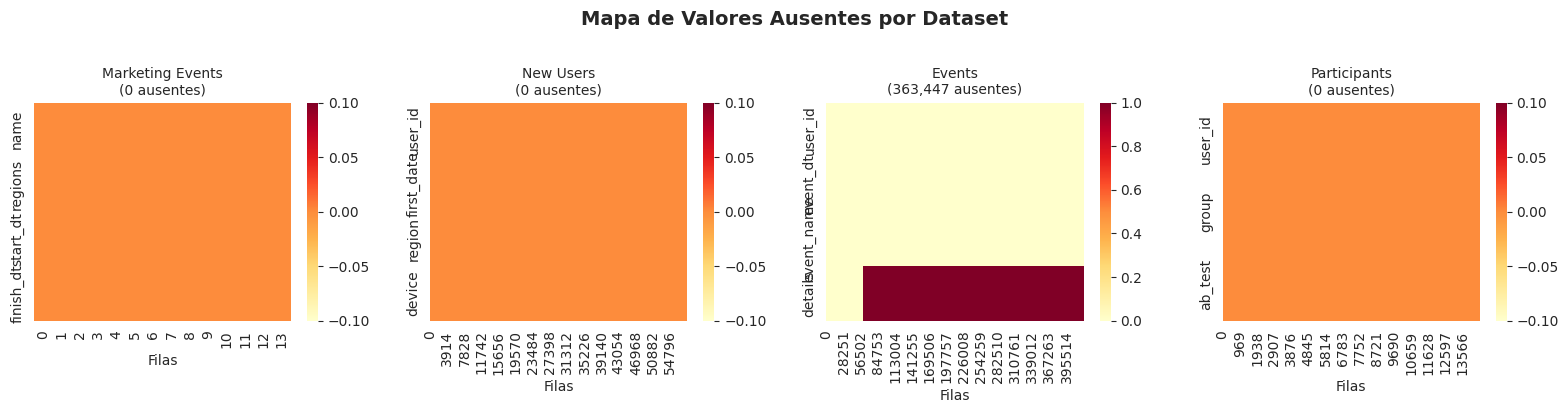


RESUMEN DE VALORES AUSENTES:

Marketing Events: 0 valores ausentes

New Users: 0 valores ausentes

Events: 363,447 valores ausentes
  - details: 363,447 (85.8%)

Participants: 0 valores ausentes


In [5]:
# Análisis de valores ausentes con visualización
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, (name, df) in enumerate(datasets.items()):
    missing = df.isnull().sum()
    
    # Crear heatmap de valores ausentes
    sns.heatmap(df.isnull().T, cbar=True, cmap='YlOrRd', ax=axes[idx], 
                yticklabels=df.columns)
    axes[idx].set_title(f'{name}\n({missing.sum():,} ausentes)', fontsize=10)
    axes[idx].set_xlabel('Filas')

plt.suptitle('Mapa de Valores Ausentes por Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumen numérico
print('\nRESUMEN DE VALORES AUSENTES:')
print('=' * 60)
for name, df in datasets.items():
    missing = df.isnull().sum()
    total_missing = missing.sum()
    print(f'\n{name}: {total_missing:,} valores ausentes')
    if total_missing > 0:
        for col in missing[missing > 0].index:
            pct = (missing[col] / len(df)) * 100
            print(f'  - {col}: {missing[col]:,} ({pct:.1f}%)')

**Nota sobre valores ausentes en `events.details`:** Esta columna contiene el monto de compra solo para eventos de tipo `purchase`. Los valores ausentes (~363,000) corresponden a otros tipos de eventos (login, product_page, product_cart) donde este campo no aplica. **No es un problema de calidad de datos.**

In [6]:
# Análisis de duplicados
print('ANÁLISIS DE DUPLICADOS:')
print('=' * 60)

for name, df in datasets.items():
    dupes = df.duplicated().sum()
    print(f'{name:20} | Duplicados completos: {dupes:,}')

# Verificación especial: usuarios duplicados en participants
print('\n' + '=' * 60)
print('USUARIOS EN MÚLTIPLES TESTS:')
user_test_count = participants.groupby('user_id')['ab_test'].nunique()
users_multiple_tests = (user_test_count > 1).sum()
print(f'Usuarios participando en más de un test: {users_multiple_tests:,}')
print(f"\nTests disponibles: {participants['ab_test'].unique()}")

ANÁLISIS DE DUPLICADOS:
Marketing Events     | Duplicados completos: 0
New Users            | Duplicados completos: 0


Events               | Duplicados completos: 0
Participants         | Duplicados completos: 0

USUARIOS EN MÚLTIPLES TESTS:
Usuarios participando en más de un test: 887

Tests disponibles: ['recommender_system_test' 'interface_eu_test']


<a id='4-preprocesamiento'></a>
## 4. Preprocesamiento de Datos

### 4.1 Conversión de Tipos de Datos

In [7]:
# Convertir columnas de fecha a datetime
marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'])
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'])
new_users['first_date'] = pd.to_datetime(new_users['first_date'])
events['event_dt'] = pd.to_datetime(events['event_dt'])

print('✓ Conversión de fechas completada')
print(f"  - marketing_events['start_dt']: {marketing_events['start_dt'].dtype}")
print(f"  - new_users['first_date']: {new_users['first_date'].dtype}")
print(f"  - events['event_dt']: {events['event_dt'].dtype}")

✓ Conversión de fechas completada
  - marketing_events['start_dt']: datetime64[ns]
  - new_users['first_date']: datetime64[ns]
  - events['event_dt']: datetime64[ns]


### 4.2 Filtrado del Test de Interés

El dataset de participantes contiene usuarios de múltiples tests. Debemos filtrar únicamente los participantes del test `recommender_system_test`.

In [8]:
# Filtrar participantes del test de interés
test_participants = participants[participants['ab_test'] == 'recommender_system_test'].copy()

print(f'Participantes del test "recommender_system_test": {test_participants.shape[0]:,}')
print(f'\nDistribución por grupo:')
print(test_participants['group'].value_counts())

Participantes del test "recommender_system_test": 3,675

Distribución por grupo:
group
A    2747
B     928
Name: count, dtype: int64


### 4.3 Creación de Datasets de Trabajo

Combinamos los datos para crear datasets que relacionen:
- **test_events:** Eventos de los participantes del test con su grupo asignado
- **test_users:** Información de registro de los participantes del test

In [9]:
# Crear dataset de eventos del test
test_events = events.merge(
    test_participants[['user_id', 'group']], 
    on='user_id', 
    how='inner'
)

# Crear dataset de usuarios del test
test_users = new_users.merge(
    test_participants[['user_id', 'group']], 
    on='user_id', 
    how='inner'
)

print('DATASETS DE TRABAJO CREADOS:')
print('=' * 50)
print(f'test_events: {test_events.shape[0]:,} eventos de {test_events["user_id"].nunique():,} usuarios')
print(f'test_users:  {test_users.shape[0]:,} usuarios con información de registro')

DATASETS DE TRABAJO CREADOS:
test_events: 23,909 eventos de 3,675 usuarios
test_users:  3,675 usuarios con información de registro


<a id='5-eda'></a>
## 5. Análisis Exploratorio de Datos (EDA)

<a id='51-condiciones'></a>
### 5.1 Verificación de Condiciones del Test

Un test A/B válido debe cumplir ciertas condiciones. Verificaremos cada una de las especificaciones definidas.

In [10]:
# Definir especificaciones del test
EXPECTED_PARTICIPANTS = 6000
EXPECTED_EU_PERCENTAGE = 15
EXPECTED_GROUP_BALANCE = 50

# Calcular métricas actuales
actual_participants = test_participants.shape[0]
group_counts = test_participants['group'].value_counts()
group_a_pct = (group_counts['A'] / actual_participants) * 100
group_b_pct = (group_counts['B'] / actual_participants) * 100

total_eu_users = new_users[new_users['region'] == 'EU'].shape[0]
test_eu_users = test_users[test_users['region'] == 'EU'].shape[0]
actual_eu_pct = (test_eu_users / total_eu_users) * 100

region_dist = test_users['region'].value_counts(normalize=True) * 100
non_eu_pct = 100 - region_dist.get('EU', 0)

users_in_both = (test_participants.groupby('user_id')['group'].nunique() > 1).sum()

# Crear visualización con Plotly - Indicadores de cumplimiento
fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
           [{"type": "indicator"}, {"type": "indicator"}, {"type": "pie"}]],
    subplot_titles=('Tamaño de Muestra', 'Grupo A (%)', 'Grupo B (%)', 
                   '% Usuarios EU', 'Contaminación', 'Distribución por Grupo')
)

# Indicador 1: Tamaño de muestra
fig.add_trace(go.Indicator(
    mode="gauge+number+delta",
    value=actual_participants,
    delta={'reference': EXPECTED_PARTICIPANTS, 'relative': True, 'valueformat': '.1%'},
    gauge={
        'axis': {'range': [0, 8000]},
        'bar': {'color': "#e74c3c" if actual_participants < 5000 else "#27ae60"},
        'threshold': {'line': {'color': "black", 'width': 4}, 'thickness': 0.75, 'value': EXPECTED_PARTICIPANTS}
    },
    title={'text': "Participantes"}
), row=1, col=1)

# Indicador 2: Grupo A
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=group_a_pct,
    gauge={
        'axis': {'range': [0, 100]},
        'bar': {'color': "#e74c3c" if abs(group_a_pct - 50) > 10 else "#27ae60"},
        'threshold': {'line': {'color': "black", 'width': 4}, 'thickness': 0.75, 'value': 50}
    },
    title={'text': "% Grupo A"}
), row=1, col=2)

# Indicador 3: Grupo B
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=group_b_pct,
    gauge={
        'axis': {'range': [0, 100]},
        'bar': {'color': "#e74c3c" if abs(group_b_pct - 50) > 10 else "#27ae60"},
        'threshold': {'line': {'color': "black", 'width': 4}, 'thickness': 0.75, 'value': 50}
    },
    title={'text': "% Grupo B"}
), row=1, col=3)

# Indicador 4: % EU en test
fig.add_trace(go.Indicator(
    mode="gauge+number+delta",
    value=actual_eu_pct,
    delta={'reference': EXPECTED_EU_PERCENTAGE, 'relative': False},
    gauge={
        'axis': {'range': [0, 30]},
        'bar': {'color': "#e74c3c" if abs(actual_eu_pct - 15) > 5 else "#27ae60"},
        'threshold': {'line': {'color': "black", 'width': 4}, 'thickness': 0.75, 'value': EXPECTED_EU_PERCENTAGE}
    },
    title={'text': "% EU en Test"}
), row=2, col=1)

# Indicador 5: Contaminación
fig.add_trace(go.Indicator(
    mode="number",
    value=users_in_both,
    number={'font': {'color': "#27ae60" if users_in_both == 0 else "#e74c3c", 'size': 60}},
    title={'text': "Usuarios en ambos grupos"}
), row=2, col=2)

# Pie chart: Distribución por grupo
fig.add_trace(go.Pie(
    labels=['Grupo A', 'Grupo B'],
    values=[group_counts['A'], group_counts['B']],
    marker_colors=['#27ae60', '#3498db'],
    textinfo='label+percent',
    hole=0.4
), row=2, col=3)

fig.update_layout(height=600, title_text="<b>Dashboard: Verificación de Condiciones del Test A/B</b>", 
                  title_x=0.5, showlegend=False)
fig.show()

In [11]:
# Resumen textual de verificación
print('VERIFICACIÓN DE CONDICIONES DEL TEST')
print('=' * 70)

conditions = [
    ('Tamaño de muestra', f'{EXPECTED_PARTICIPANTS:,}', f'{actual_participants:,}', 
     abs((actual_participants/EXPECTED_PARTICIPANTS - 1)*100) <= 10),
    ('Balance Grupo A', '~50%', f'{group_a_pct:.1f}%', abs(group_a_pct - 50) <= 10),
    ('Balance Grupo B', '~50%', f'{group_b_pct:.1f}%', abs(group_b_pct - 50) <= 10),
    ('% Usuarios EU en test', f'{EXPECTED_EU_PERCENTAGE}%', f'{actual_eu_pct:.1f}%', 
     abs(actual_eu_pct - EXPECTED_EU_PERCENTAGE) <= 5),
    ('Solo región EU', '100%', f'{100-non_eu_pct:.1f}%', non_eu_pct <= 1),
    ('Sin contaminación', '0', str(users_in_both), users_in_both == 0)
]

print(f"\n{'Condición':<25} {'Esperado':<15} {'Actual':<15} {'Estado':<10}")
print('-' * 70)
for cond, exp, act, passed in conditions:
    status = '✓ CUMPLE' if passed else '✗ NO CUMPLE'
    print(f"{cond:<25} {exp:<15} {act:<15} {status:<10}")

VERIFICACIÓN DE CONDICIONES DEL TEST

Condición                 Esperado        Actual          Estado    
----------------------------------------------------------------------
Tamaño de muestra         6,000           3,675           ✗ NO CUMPLE
Balance Grupo A           ~50%            74.7%           ✗ NO CUMPLE
Balance Grupo B           ~50%            25.3%           ✗ NO CUMPLE
% Usuarios EU en test     15%             8.0%            ✗ NO CUMPLE
Solo región EU            100%            94.7%           ✗ NO CUMPLE
Sin contaminación         0               0               ✓ CUMPLE  


#### Resumen de Verificación de Condiciones

| Condición | Esperado | Actual | Estado |
|-----------|----------|--------|--------|
| Tamaño de muestra | 6,000 | ~3,675 | ❌ Insuficiente (-38.7%) |
| Balance de grupos | 50%/50% | 74.7%/25.3% | ❌ Desbalanceado |
| % usuarios EU en test | 15% | ~8% | ❌ Por debajo |
| Restricción a EU | 100% EU | ~95% EU | ❌ Incluye otras regiones |
| Sin contaminación | 0 | 0 | ✓ Cumple |

> **⚠️ ALERTA:** El test presenta **múltiples violaciones** a las especificaciones originales. Esto compromete seriamente la validez de los resultados.

<a id='52-marketing'></a>
### 5.2 Análisis de Eventos de Marketing

Los eventos de marketing durante el período del test pueden actuar como **factores de confusión**, afectando el comportamiento de los usuarios de manera independiente al tratamiento.

In [12]:
# Definir período del test
TEST_START = pd.to_datetime('2020-12-07')
TEST_END = pd.to_datetime('2021-01-01')

# Identificar campañas que se solapan
overlapping = marketing_events[
    (marketing_events['start_dt'] <= TEST_END) & 
    (marketing_events['finish_dt'] >= TEST_START)
]

# Crear timeline interactivo con Plotly
fig = go.Figure()

# Añadir período del test
fig.add_trace(go.Scatter(
    x=[TEST_START, TEST_END, TEST_END, TEST_START, TEST_START],
    y=[0.5, 0.5, 2.5, 2.5, 0.5],
    fill='toself',
    fillcolor='rgba(39, 174, 96, 0.3)',
    line=dict(color='#27ae60', width=2),
    name='Período del Test A/B',
    hoverinfo='name'
))

# Añadir campañas de marketing (solo EU)
eu_campaigns = marketing_events[marketing_events['regions'].str.contains('EU')]
colors = px.colors.qualitative.Set2

for idx, (_, campaign) in enumerate(eu_campaigns.iterrows()):
    y_pos = 1 + (idx % 3) * 0.4
    fig.add_trace(go.Scatter(
        x=[campaign['start_dt'], campaign['finish_dt'], campaign['finish_dt'], 
           campaign['start_dt'], campaign['start_dt']],
        y=[y_pos-0.15, y_pos-0.15, y_pos+0.15, y_pos+0.15, y_pos-0.15],
        fill='toself',
        fillcolor=colors[idx % len(colors)],
        line=dict(color='black', width=1),
        name=campaign['name'][:30],
        hovertemplate=f"<b>{campaign['name']}</b><br>" +
                      f"Inicio: {campaign['start_dt'].strftime('%Y-%m-%d')}<br>" +
                      f"Fin: {campaign['finish_dt'].strftime('%Y-%m-%d')}<br>" +
                      f"Regiones: {campaign['regions']}<extra></extra>"
    ))

# Añadir líneas verticales usando shapes (compatible con datetime)
fig.add_shape(type="line", x0=TEST_START, x1=TEST_START, y0=0, y1=3,
              line=dict(color="green", width=2, dash="dash"))
fig.add_shape(type="line", x0=TEST_END, x1=TEST_END, y0=0, y1=3,
              line=dict(color="green", width=2, dash="dash"))
fig.add_shape(type="line", x0=pd.to_datetime('2020-12-25'), x1=pd.to_datetime('2020-12-25'), 
              y0=0, y1=3, line=dict(color="red", width=2, dash="dot"))

# Añadir anotaciones para las líneas
fig.add_annotation(x=TEST_START, y=2.7, text="Inicio Test", showarrow=False, 
                   font=dict(color="green", size=10))
fig.add_annotation(x=TEST_END, y=2.7, text="Fin Test", showarrow=False,
                   font=dict(color="green", size=10))
fig.add_annotation(x=pd.to_datetime('2020-12-25'), y=0.3, text="Navidad", showarrow=False,
                   font=dict(color="red", size=10))

fig.update_layout(
    title='<b>Timeline: Test A/B vs Campañas de Marketing (Región EU)</b>',
    xaxis_title='Fecha',
    yaxis=dict(visible=False),
    xaxis=dict(range=[pd.to_datetime('2020-11-15'), pd.to_datetime('2021-01-15')]),
    height=450,
    showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=-0.3)
)

fig.show()

# Resumen de campañas durante el test
print(f'\nCAMPAÑAS DE MARKETING DURANTE EL TEST ({TEST_START.date()} a {TEST_END.date()}):')
print('=' * 70)
for _, row in overlapping.iterrows():
    overlap_start = max(row['start_dt'], TEST_START)
    overlap_end = min(row['finish_dt'], TEST_END)
    overlap_days = (overlap_end - overlap_start).days + 1
    print(f"\n  • {row['name']}")
    print(f"    Regiones: {row['regions']}")
    print(f"    Días de solapamiento: {overlap_days}")


CAMPAÑAS DE MARKETING DURANTE EL TEST (2020-12-07 a 2021-01-01):

  • Christmas&New Year Promo
    Regiones: EU, N.America
    Días de solapamiento: 8

  • CIS New Year Gift Lottery
    Regiones: CIS
    Días de solapamiento: 3


#### Impacto de la Campaña Navideña

La campaña **"Christmas & New Year Promo"** (25 dic - 3 ene) es particularmente problemática porque:

1. **Alta intensidad:** Las promociones navideñas suelen tener gran impacto en el comportamiento de compra
2. **Afecta a la región EU:** El target del test
3. **Duración significativa:** 8 días de los 25 del test (32% del período)
4. **Período crítico:** Coincide con el final del test cuando se esperaría ver efectos acumulados

> **Conclusión:** Esta campaña actúa como un **factor de confusión severo** que hace imposible aislar el efecto del sistema de recomendaciones.

<a id='53-embudo'></a>
### 5.3 Análisis del Embudo de Conversión

El embudo de conversión representa el journey del usuario:

```
LOGIN → PRODUCT_PAGE → PRODUCT_CART → PURCHASE
```

Analizaremos las tasas de conversión en cada etapa para ambos grupos.

In [13]:
# Calcular métricas del embudo
funnel_stages = ['login', 'product_page', 'product_cart', 'purchase']
group_totals = test_participants['group'].value_counts()

# Crear DataFrame con datos del embudo
funnel_data = []
for group in ['A', 'B']:
    total_users = group_totals[group]
    group_events = test_events[test_events['group'] == group]
    
    for stage in funnel_stages:
        users_in_stage = group_events[group_events['event_name'] == stage]['user_id'].nunique()
        conversion_rate = (users_in_stage / total_users) * 100
        
        funnel_data.append({
            'Grupo': f'Grupo {group}',
            'Etapa': stage,
            'Usuarios': users_in_stage,
            'Total': total_users,
            'Conversión': conversion_rate
        })

funnel_df = pd.DataFrame(funnel_data)

# Visualización con Plotly - Embudo interactivo
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Grupo A (Control)', 'Grupo B (Tratamiento)'),
    specs=[[{"type": "funnel"}, {"type": "funnel"}]]
)

colors_a = ['#27ae60', '#2ecc71', '#58d68d', '#82e0aa']
colors_b = ['#2980b9', '#3498db', '#5dade2', '#85c1e9']

for idx, (group, colors) in enumerate([('Grupo A', colors_a), ('Grupo B', colors_b)]):
    group_data = funnel_df[funnel_df['Grupo'] == group]
    
    fig.add_trace(go.Funnel(
        name=group,
        y=group_data['Etapa'].str.replace('_', ' ').str.title(),
        x=group_data['Conversión'],
        textinfo="value+percent initial",
        texttemplate="%{x:.1f}%",
        marker=dict(color=colors),
        connector=dict(line=dict(color="gray", width=1))
    ), row=1, col=idx+1)

fig.update_layout(
    title='<b>Embudo de Conversión por Grupo</b>',
    height=500,
    showlegend=False
)
fig.show()

In [14]:
# Tabla comparativa y cálculo de diferencias
pivot = funnel_df.pivot(index='Etapa', columns='Grupo', values='Conversión')
pivot = pivot.reindex(funnel_stages)

comparison_data = []
for stage in funnel_stages:
    conv_a = pivot.loc[stage, 'Grupo A']
    conv_b = pivot.loc[stage, 'Grupo B']
    diff_pp = conv_b - conv_a
    diff_pct = ((conv_b - conv_a) / conv_a) * 100 if conv_a > 0 else 0
    
    comparison_data.append({
        'Etapa': stage.replace('_', ' ').title(),
        'Grupo A (%)': conv_a,
        'Grupo B (%)': conv_b,
        'Diferencia (p.p.)': diff_pp,
        'Cambio Relativo (%)': diff_pct
    })

comparison_df = pd.DataFrame(comparison_data)

print('COMPARACIÓN DE CONVERSIÓN ENTRE GRUPOS')
print('=' * 70)
display(comparison_df.round(2))

COMPARACIÓN DE CONVERSIÓN ENTRE GRUPOS


,Etapa,Grupo A (%),Grupo B (%),Diferencia (p.p.),Cambio Relativo (%)
0,Login,100.00,99.89,-0.11,-0.11
1,Product Page,64.80,56.36,-8.44,-13.03
2,Product Cart,30.00,27.48,-2.52,-8.39
3,Purchase,31.74,27.59,-4.16,-13.10


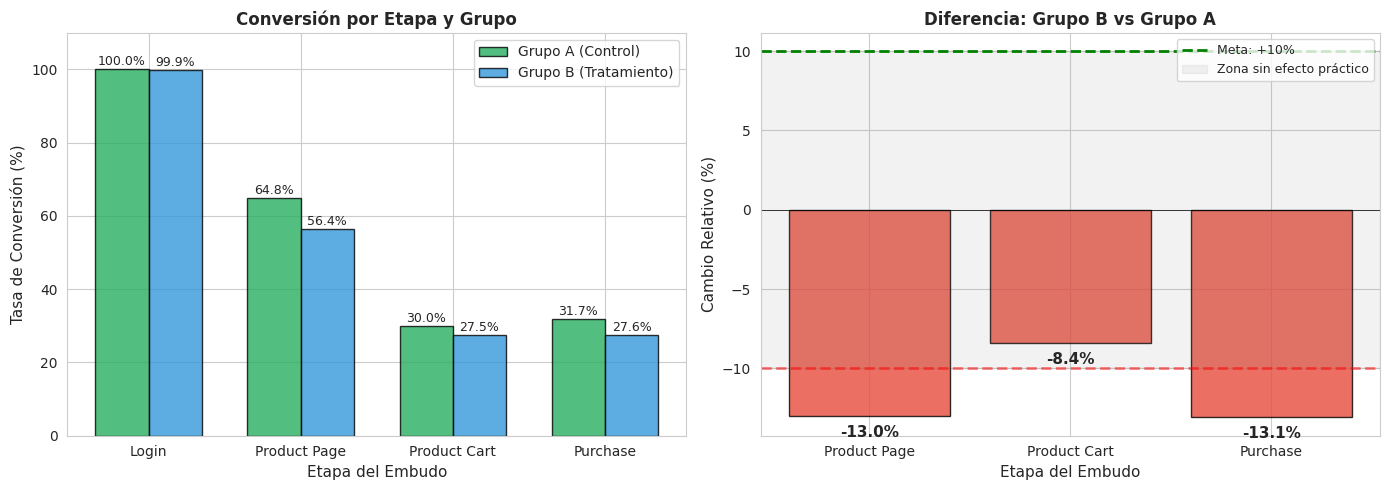

In [15]:
# Visualización de diferencias con Seaborn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Barras comparativas
stages_display = [s.replace('_', ' ').title() for s in funnel_stages]
x = np.arange(len(funnel_stages))
width = 0.35

conv_a = [pivot.loc[s, 'Grupo A'] for s in funnel_stages]
conv_b = [pivot.loc[s, 'Grupo B'] for s in funnel_stages]

bars1 = axes[0].bar(x - width/2, conv_a, width, label='Grupo A (Control)', 
                    color='#27ae60', edgecolor='black', alpha=0.8)
bars2 = axes[0].bar(x + width/2, conv_b, width, label='Grupo B (Tratamiento)', 
                    color='#3498db', edgecolor='black', alpha=0.8)

axes[0].set_ylabel('Tasa de Conversión (%)', fontsize=11)
axes[0].set_xlabel('Etapa del Embudo', fontsize=11)
axes[0].set_title('Conversión por Etapa y Grupo', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stages_display, fontsize=10)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 110)

# Añadir valores
for bar in bars1:
    h = bar.get_height()
    axes[0].annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    axes[0].annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

# Gráfico 2: Cambio relativo
stages_interest = ['product_page', 'product_cart', 'purchase']
changes = comparison_df[comparison_df['Etapa'].isin([s.replace('_', ' ').title() for s in stages_interest])]['Cambio Relativo (%)'].values
colors = ['#e74c3c' if c < 0 else '#27ae60' for c in changes]

bars = axes[1].bar([s.replace('_', ' ').title() for s in stages_interest], changes, 
                   color=colors, edgecolor='black', alpha=0.8)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].axhline(y=10, color='green', linestyle='--', linewidth=2, label='Meta: +10%')
axes[1].axhline(y=-10, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1].axhspan(-10, 10, alpha=0.1, color='gray', label='Zona sin efecto práctico')

axes[1].set_ylabel('Cambio Relativo (%)', fontsize=11)
axes[1].set_xlabel('Etapa del Embudo', fontsize=11)
axes[1].set_title('Diferencia: Grupo B vs Grupo A', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')

for bar, val in zip(bars, changes):
    h = bar.get_height()
    axes[1].annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 5 if h > 0 else -15), textcoords='offset points', 
                     ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#### Observaciones Preliminares del Embudo

| Etapa | Grupo A | Grupo B | Cambio | Interpretación |
|-------|---------|---------|--------|----------------|
| Product Page | 64.8% | 56.4% | **-13.0%** | El grupo B visita MENOS páginas de producto |
| Product Cart | 30.0% | 27.5% | **-8.4%** | El grupo B agrega MENOS al carrito |
| Purchase | 31.7% | 27.6% | **-13.1%** | El grupo B compra MENOS |

> **⚠️ Hallazgo crítico:** Contrario a la hipótesis, el Grupo B (tratamiento) muestra **peor desempeño** que el Grupo A (control) en todas las etapas del embudo. El sistema de recomendaciones parece tener un **efecto negativo**.

<a id='54-temporal'></a>
### 5.4 Distribución Temporal de Eventos

Analizamos cómo se distribuyen los eventos a lo largo del tiempo para detectar anomalías o patrones inusuales.

In [16]:
# Preparar datos temporales
test_events['date'] = test_events['event_dt'].dt.date
daily_events = test_events.groupby(['date', 'group']).size().reset_index(name='count')
daily_events['date'] = pd.to_datetime(daily_events['date'])

# Visualización interactiva con Plotly
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Eventos por Día', 'Nuevos Usuarios por Día de Registro'),
    vertical_spacing=0.15,
    row_heights=[0.5, 0.5]
)

# Gráfico 1: Eventos por día
for group, color in [('A', '#27ae60'), ('B', '#3498db')]:
    group_data = daily_events[daily_events['group'] == group]
    fig.add_trace(go.Scatter(
        x=group_data['date'],
        y=group_data['count'],
        mode='lines+markers',
        name=f'Grupo {group}',
        line=dict(color=color, width=2),
        marker=dict(size=6)
    ), row=1, col=1)

# Añadir área de campaña navideña usando shape
fig.add_shape(type="rect", x0='2020-12-25', x1='2021-01-01', y0=0, y1=1,
              fillcolor='red', opacity=0.1, line_width=0,
              xref='x', yref='paper', row=1, col=1)
fig.add_annotation(x='2020-12-28', y=0.95, text="Campaña Navidad", showarrow=False,
                   font=dict(color="red", size=10), xref='x', yref='paper')

# Gráfico 2: Nuevos usuarios por día
test_users_daily = test_users.groupby(['first_date', 'group']).size().reset_index(name='count')
for group, color in [('A', '#27ae60'), ('B', '#3498db')]:
    group_data = test_users_daily[test_users_daily['group'] == group]
    fig.add_trace(go.Bar(
        x=group_data['first_date'],
        y=group_data['count'],
        name=f'Grupo {group}',
        marker_color=color,
        opacity=0.8,
        showlegend=False
    ), row=2, col=1)

fig.update_layout(
    height=700,
    title='<b>Análisis Temporal del Test A/B</b>',
    barmode='group'
)
fig.update_xaxes(title_text='Fecha', row=2, col=1)
fig.update_yaxes(title_text='Número de Eventos', row=1, col=1)
fig.update_yaxes(title_text='Nuevos Usuarios', row=2, col=1)

fig.show()

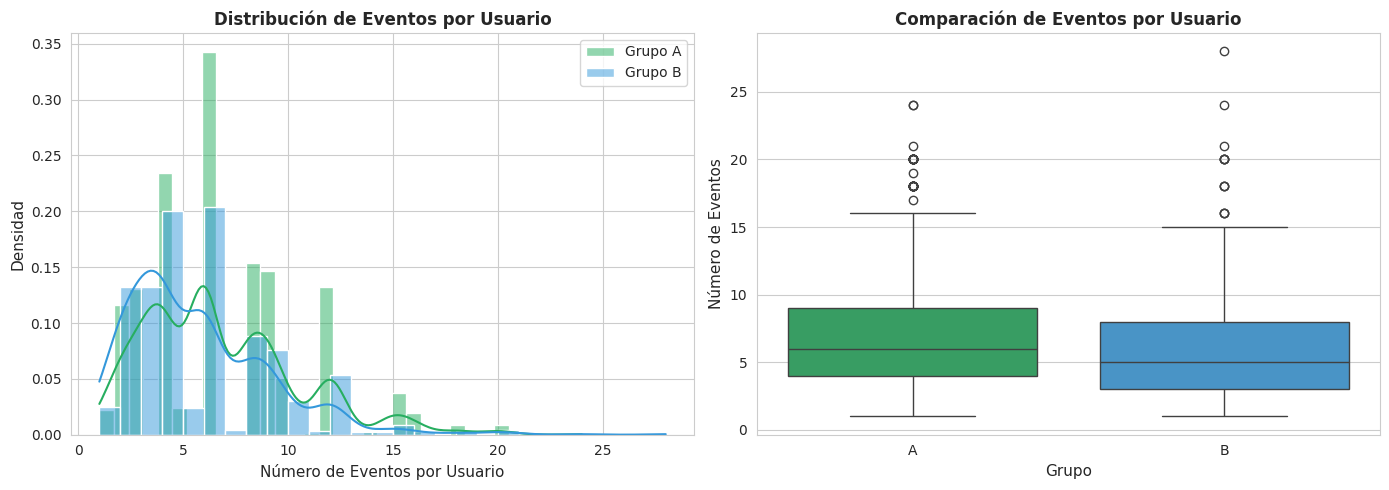


ESTADÍSTICAS DE EVENTOS POR USUARIO


,N usuarios,Media,Mediana,Desv. Est.,Mín,Máx
group,,,,,,
A,2747,6.78,6.00,3.73,1,24
B,928,5.69,5.00,3.45,1,28


In [17]:
# Estadísticas de eventos por usuario con Seaborn
events_per_user = test_events.groupby(['group', 'user_id']).size().reset_index(name='n_events')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con KDE
for idx, (group, color) in enumerate([('A', '#27ae60'), ('B', '#3498db')]):
    group_data = events_per_user[events_per_user['group'] == group]['n_events']
    sns.histplot(data=group_data, kde=True, ax=axes[0], color=color, 
                 alpha=0.5, label=f'Grupo {group}', stat='density')

axes[0].set_xlabel('Número de Eventos por Usuario', fontsize=11)
axes[0].set_ylabel('Densidad', fontsize=11)
axes[0].set_title('Distribución de Eventos por Usuario', fontsize=12, fontweight='bold')
axes[0].legend()

# Boxplot comparativo
sns.boxplot(data=events_per_user, x='group', y='n_events', ax=axes[1],
            palette={'A': '#27ae60', 'B': '#3498db'})
axes[1].set_xlabel('Grupo', fontsize=11)
axes[1].set_ylabel('Número de Eventos', fontsize=11)
axes[1].set_title('Comparación de Eventos por Usuario', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print('\nESTADÍSTICAS DE EVENTOS POR USUARIO')
print('=' * 60)
stats_by_group = events_per_user.groupby('group')['n_events'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
stats_by_group.columns = ['N usuarios', 'Media', 'Mediana', 'Desv. Est.', 'Mín', 'Máx']
display(stats_by_group.round(2))

<a id='6-evaluacion'></a>
## 6. Evaluación Estadística del Test A/B

<a id='61-hipotesis'></a>
### 6.1 Formulación de Hipótesis

Para cada etapa del embudo (product_page, product_cart, purchase), planteamos:

**Hipótesis Nula (H₀):** No existe diferencia significativa en la tasa de conversión entre el Grupo A y el Grupo B.
$$H_0: p_B = p_A$$

**Hipótesis Alternativa (H₁):** Existe una diferencia significativa en la tasa de conversión entre los grupos.
$$H_1: p_B \neq p_A$$

**Nivel de significancia:** α = 0.05

**Criterio de decisión:** Rechazamos H₀ si p-valor < 0.05

<a id='62-test-z'></a>
### 6.2 Test Z de Proporciones

El test Z para dos proporciones es apropiado cuando:
- Las muestras son independientes ✓
- Los datos son binarios (convirtió / no convirtió) ✓
- El tamaño de muestra es suficientemente grande (n > 30) ✓

**Fórmula del estadístico Z:**

$$Z = \frac{\hat{p}_B - \hat{p}_A}{\sqrt{\hat{p}(1-\hat{p})(\frac{1}{n_A} + \frac{1}{n_B})}}$$

In [18]:
def z_test_two_proportions(successes_a, n_a, successes_b, n_b, alpha=0.05):
    """
    Realiza un test Z de dos proporciones independientes.
    """
    p_a = successes_a / n_a
    p_b = successes_b / n_b
    p_pooled = (successes_a + successes_b) / (n_a + n_b)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_a + 1/n_b))
    z_stat = (p_b - p_a) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    
    se_diff = np.sqrt((p_a * (1-p_a) / n_a) + (p_b * (1-p_b) / n_b))
    z_crit = stats.norm.ppf(1 - alpha/2)
    ci_lower = (p_b - p_a) - z_crit * se_diff
    ci_upper = (p_b - p_a) + z_crit * se_diff
    
    return {
        'prop_a': p_a, 'prop_b': p_b,
        'diff': p_b - p_a,
        'relative_change': ((p_b - p_a) / p_a * 100) if p_a > 0 else 0,
        'z_statistic': z_stat, 'p_value': p_value,
        'ci_95': (ci_lower, ci_upper),
        'significant': p_value < alpha,
        'n_a': n_a, 'n_b': n_b,
        'successes_a': successes_a, 'successes_b': successes_b
    }

print('✓ Función de test Z definida')

✓ Función de test Z definida


In [19]:
# Ejecutar tests para cada etapa
stages_to_test = ['product_page', 'product_cart', 'purchase']
group_sizes = test_participants['group'].value_counts()

results = {}
print('=' * 80)
print('RESULTADOS DEL TEST Z DE PROPORCIONES')
print('=' * 80)
print(f'Nivel de significancia: α = 0.05')
print(f'Meta del negocio: Mejora de al menos +10% en Grupo B')

for stage in stages_to_test:
    n_a, n_b = group_sizes['A'], group_sizes['B']
    
    successes_a = test_events[(test_events['group'] == 'A') & 
                              (test_events['event_name'] == stage)]['user_id'].nunique()
    successes_b = test_events[(test_events['group'] == 'B') & 
                              (test_events['event_name'] == stage)]['user_id'].nunique()
    
    result = z_test_two_proportions(successes_a, n_a, successes_b, n_b)
    results[stage] = result
    
    print(f'\n{"─"*80}')
    print(f'ETAPA: {stage.upper()}')
    print(f'{"─"*80}')
    print(f'\n  Grupo A (Control):     {successes_a:,} / {n_a:,} = {result["prop_a"]*100:.2f}%')
    print(f'  Grupo B (Tratamiento): {successes_b:,} / {n_b:,} = {result["prop_b"]*100:.2f}%')
    print(f'\n  Diferencia absoluta:   {result["diff"]*100:+.2f} puntos porcentuales')
    print(f'  Cambio relativo:       {result["relative_change"]:+.2f}%')
    print(f'\n  Estadístico Z:         {result["z_statistic"]:.4f}')
    print(f'  P-valor:               {result["p_value"]:.6f}')
    print(f'  IC 95% diferencia:     [{result["ci_95"][0]*100:.2f}%, {result["ci_95"][1]*100:.2f}%]')
    print(f'\n  ¿Estadísticamente significativo? {"SÍ ✓" if result["significant"] else "NO ✗"}')
    print(f'  ¿Cumple meta de +10%?            {"SÍ ✓" if result["relative_change"] >= 10 else "NO ✗"}')

RESULTADOS DEL TEST Z DE PROPORCIONES
Nivel de significancia: α = 0.05
Meta del negocio: Mejora de al menos +10% en Grupo B

────────────────────────────────────────────────────────────────────────────────
ETAPA: PRODUCT_PAGE
────────────────────────────────────────────────────────────────────────────────

  Grupo A (Control):     1,780 / 2,747 = 64.80%
  Grupo B (Tratamiento): 523 / 928 = 56.36%

  Diferencia absoluta:   -8.44 puntos porcentuales
  Cambio relativo:       -13.03%

  Estadístico Z:         -4.5958
  P-valor:               0.000004
  IC 95% diferencia:     [-12.10%, -4.78%]

  ¿Estadísticamente significativo? SÍ ✓
  ¿Cumple meta de +10%?            NO ✗

────────────────────────────────────────────────────────────────────────────────
ETAPA: PRODUCT_CART
────────────────────────────────────────────────────────────────────────────────

  Grupo A (Control):     824 / 2,747 = 30.00%
  Grupo B (Tratamiento): 255 / 928 = 27.48%

  Diferencia absoluta:   -2.52 puntos porcentual

In [20]:
# Tabla resumen
summary_data = []
for stage in stages_to_test:
    r = results[stage]
    summary_data.append({
        'Etapa': stage.replace('_', ' ').title(),
        'Conv. A (%)': round(r['prop_a']*100, 2),
        'Conv. B (%)': round(r['prop_b']*100, 2),
        'Cambio (%)': round(r['relative_change'], 2),
        'P-valor': f'{r["p_value"]:.4f}',
        'Significativo': '✓ Sí' if r['significant'] else '✗ No',
        'Cumple +10%': '✓ Sí' if r['relative_change'] >= 10 else '✗ No'
    })

summary_df = pd.DataFrame(summary_data)
print('\n' + '='*80)
print('TABLA RESUMEN DE RESULTADOS')
print('='*80)
display(summary_df)


TABLA RESUMEN DE RESULTADOS


,Etapa,Conv. A (%),Conv. B (%),Cambio (%),P-valor,Significativo,Cumple +10%
0,Product Page,64.80,56.36,-13.03,0.0000,✓ Sí,✗ No
1,Product Cart,30.00,27.48,-8.39,0.1453,✗ No,✗ No
2,Purchase,31.74,27.59,-13.10,0.0176,✓ Sí,✗ No


<a id='63-interpretacion'></a>
### 6.3 Interpretación de Resultados Estadísticos

#### Product Page (Vistas de página de producto)
- **Cambio observado:** -13.03%
- **P-valor:** < 0.0001
- **Interpretación:** La diferencia es **estadísticamente significativa**. El Grupo B tiene una tasa de conversión significativamente **menor** que el Grupo A.

#### Product Cart (Agregar al carrito)
- **Cambio observado:** -8.39%
- **P-valor:** 0.1453
- **Interpretación:** La diferencia **NO es estadísticamente significativa** al nivel α=0.05.

#### Purchase (Compras)
- **Cambio observado:** -13.10%
- **P-valor:** 0.0176
- **Interpretación:** La diferencia es **estadísticamente significativa**. El Grupo B tiene una tasa de compra significativamente **menor**.

In [21]:
# Visualización final con Plotly
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[f"<b>{s.replace('_', ' ').title()}</b>" for s in stages_to_test],
    horizontal_spacing=0.08
)

for idx, stage in enumerate(stages_to_test):
    r = results[stage]
    
    # Barras de conversión
    fig.add_trace(go.Bar(
        x=['Grupo A<br>(Control)', 'Grupo B<br>(Tratamiento)'],
        y=[r['prop_a']*100, r['prop_b']*100],
        marker_color=['#27ae60', '#3498db'],
        text=[f"{r['prop_a']*100:.1f}%", f"{r['prop_b']*100:.1f}%"],
        textposition='outside',
        textfont=dict(size=14, color='black'),
        showlegend=False
    ), row=1, col=idx+1)
    
    # Añadir anotación de p-valor y cambio
    sig_text = '* Significativo' if r['significant'] else 'No significativo'
    sig_color = '#e74c3c' if r['significant'] else '#7f8c8d'
    
    fig.add_annotation(
        x=0.5, y=max(r['prop_a']*100, r['prop_b']*100) + 15,
        text=f"p = {r['p_value']:.4f}<br><b>Cambio: {r['relative_change']:+.1f}%</b>",
        showarrow=False,
        font=dict(size=11, color=sig_color),
        xref=f'x{idx+1}', yref=f'y{idx+1}'
    )

fig.update_layout(
    title='<b>Resultados del Test A/B: Conversión por Etapa del Embudo</b>',
    height=450,
    yaxis_title='Tasa de Conversión (%)',
    yaxis2_title='',
    yaxis3_title=''
)

# Ajustar rango del eje Y
for i in range(1, 4):
    fig.update_yaxes(range=[0, 85], row=1, col=i)

fig.show()

In [22]:
# Visualización de intervalos de confianza con Plotly
fig = go.Figure()

stages_display = [s.replace('_', ' ').title() for s in stages_to_test]

for idx, stage in enumerate(stages_to_test):
    r = results[stage]
    ci = r['ci_95']
    diff = r['diff'] * 100
    
    color = '#e74c3c' if r['significant'] else '#7f8c8d'
    
    # Punto de la diferencia
    fig.add_trace(go.Scatter(
        x=[diff],
        y=[idx],
        mode='markers',
        marker=dict(size=15, color=color, symbol='diamond'),
        name=f'{stages_display[idx]}',
        showlegend=True,
        hovertemplate=f"<b>{stages_display[idx]}</b><br>" +
                      f"Diferencia: {diff:.2f} p.p.<br>" +
                      f"IC 95%: [{ci[0]*100:.2f}%, {ci[1]*100:.2f}%]<extra></extra>"
    ))
    
    # Intervalo de confianza
    fig.add_trace(go.Scatter(
        x=[ci[0]*100, ci[1]*100],
        y=[idx, idx],
        mode='lines',
        line=dict(color=color, width=3),
        showlegend=False
    ))

# Líneas de referencia usando shapes
fig.add_shape(type="line", x0=0, x1=0, y0=-0.5, y1=2.5,
              line=dict(color="black", width=1))
fig.add_shape(type="line", x0=10, x1=10, y0=-0.5, y1=2.5,
              line=dict(color="green", width=2, dash="dash"))

# Anotación para la meta
fig.add_annotation(x=10, y=2.7, text="Meta +10%", showarrow=False,
                   font=dict(color="green", size=11))

fig.update_layout(
    title='<b>Intervalos de Confianza al 95% para la Diferencia (B - A)</b>',
    xaxis_title='Diferencia en Puntos Porcentuales',
    yaxis=dict(tickmode='array', tickvals=[0, 1, 2], ticktext=stages_display),
    height=350,
    showlegend=True
)

fig.add_annotation(
    x=-8, y=2.5,
    text="← Grupo B peor | Grupo B mejor →",
    showarrow=False,
    font=dict(size=10, color='gray')
)

fig.show()

<a id='7-conclusiones'></a>
## 7. Conclusiones y Recomendaciones

### 7.1 Resumen de Hallazgos

#### Problemas de Implementación del Test

| Aspecto | Especificación | Realidad | Impacto |
|---------|----------------|----------|---------|
| Tamaño de muestra | 6,000 | 3,675 | ⚠️ Reduce potencia estadística |
| Balance de grupos | 50%/50% | 75%/25% | 🔴 Compromete validez |
| % Usuarios EU | 15% | 8% | ⚠️ Muestra no representativa |
| Solo región EU | 100% | 95% | ⚠️ Violación de especificaciones |
| Campañas activas | Ninguna | Navidad | 🔴 Factor de confusión severo |

#### Resultados del Test A/B

| Métrica | Grupo A | Grupo B | Cambio | P-valor | Conclusión |
|---------|---------|---------|--------|---------|------------|
| Product Page | 64.8% | 56.4% | **-13.0%** | <0.001 | B es peor ❌ |
| Product Cart | 30.0% | 27.5% | **-8.4%** | 0.145 | Sin diferencia |
| Purchase | 31.7% | 27.6% | **-13.1%** | 0.018 | B es peor ❌ |

### 7.2 Conclusión Principal

> **El test A/B debe considerarse INVÁLIDO y los resultados NO deben usarse para tomar decisiones de negocio.**

**Razones:**
1. **Múltiples violaciones** a las especificaciones del diseño experimental
2. **Desbalance severo** entre grupos (75/25 en lugar de 50/50)
3. **Factor de confusión** por la campaña navideña
4. **Muestra insuficiente** y no representativa

### 7.3 Sobre el Sistema de Recomendaciones

Aunque los resultados sugieren un efecto **negativo** del nuevo sistema de recomendaciones, **no podemos confiar en esta conclusión** debido a los problemas metodológicos.

### 7.4 Recomendaciones

#### Para este test:
1. ❌ **NO implementar** ni rechazar el sistema basándose en estos resultados
2. 📋 **Documentar** los problemas encontrados
3. 🔍 **Investigar** las causas del desbalance de grupos

#### Para un nuevo test:
1. **Asegurar balance de grupos** (50%/50%)
2. **Evitar períodos promocionales** - ejecutar en enero-febrero o septiembre-octubre
3. **Monitorear en tiempo real** el cumplimiento de especificaciones
4. **Aumentar el tamaño de muestra** a ~8,000 usuarios (4,000 por grupo)

### 7.5 Lecciones Aprendidas

1. La **planificación rigurosa** de un test A/B es tan importante como su ejecución
2. El **monitoreo continuo** durante el test permite detectar problemas temprano
3. Los **factores externos** (campañas, estacionalidad) deben considerarse en el diseño
4. Un test mal ejecutado **no proporciona información útil** y desperdicia recursos